## How are in-demand skills trending for Data Analytics?

### Methodology

1. Aggregate skill counts by month
2. Re-analyze based on percentage of total jobs
3. Plot the demand

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Clean-up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_SE = df[(df['job_country'] == 'Sweden') & (df['job_title'] == 'Data Analyst')].copy()

Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\kposp\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\1d815e9ce232eb27db11939c44eb048fe6d2e9ab (last modified on Mon Aug  5 20:05:58 2024).


In [2]:
df_SE['job_posted_month_no'] = df_SE['job_posted_date'].dt.month

In [3]:
df_SE_explode = df_SE.explode('job_skills')

In [7]:
df_SE_pivot = df_SE_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_SE_pivot.loc['Total'] = df_SE_pivot.sum()
df_SE_pivot = df_SE_pivot[df_SE_pivot.loc['Total'].sort_values(ascending=False).index]
df_SE_pivot = df_SE_pivot.drop('Total')

df_SE_pivot

job_skills,sql,python,tableau,power bi,r,looker,excel,azure,gcp,bigquery,...,postgresql,spss,confluence,flow,hadoop,jenkins,redshift,alteryx,mysql,airflow
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,20,16,2,10,8,3,4,4,5,5,...,0,0,0,0,0,1,1,0,0,0
2,17,13,7,4,9,4,4,3,4,1,...,0,0,0,0,0,0,0,0,0,0
3,8,5,3,4,1,2,3,1,3,4,...,0,0,0,0,0,0,0,0,0,0
4,8,5,3,2,4,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,11,7,5,3,3,4,5,1,4,3,...,0,0,0,0,0,0,0,0,0,0
6,19,11,11,10,6,8,3,5,1,3,...,0,0,0,0,0,0,0,0,0,0
7,13,12,7,1,6,6,1,0,3,3,...,0,0,0,0,0,0,0,0,0,0
8,27,15,17,13,7,4,8,4,3,3,...,1,1,0,0,0,0,0,0,1,1
9,11,5,5,2,2,3,1,3,1,2,...,0,0,0,0,0,0,0,0,0,0


In [8]:
DA_totals = df_SE.groupby('job_posted_month_no').size()

In [11]:
df_SE_percent = df_SE_pivot.div(DA_totals/100, axis=0)
df_SE_percent = df_SE_percent.reset_index()
df_SE_percent['job_posted_month'] = df_SE_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_SE_percent = df_SE_percent.set_index('job_posted_month')
df_SE_percent = df_SE_percent.drop(columns=['job_posted_month_no'])

df_SE_percent

job_skills,sql,python,tableau,power bi,r,looker,excel,azure,gcp,bigquery,...,postgresql,spss,confluence,flow,hadoop,jenkins,redshift,alteryx,mysql,airflow
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,60.606061,48.484848,6.060606,30.303030,24.242424,9.090909,12.121212,12.121212,15.151515,15.151515,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.030303,3.030303,0.000000,0.000000,0.000000
Feb,80.952381,61.904762,33.333333,19.047619,42.857143,19.047619,19.047619,14.285714,19.047619,4.761905,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,57.142857,35.714286,21.428571,28.571429,7.142857,14.285714,21.428571,7.142857,21.428571,28.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,88.888889,55.555556,33.333333,22.222222,44.444444,33.333333,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,73.333333,46.666667,33.333333,20.000000,20.000000,26.666667,33.333333,6.666667,26.666667,20.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,67.857143,39.285714,39.285714,35.714286,21.428571,28.571429,10.714286,17.857143,3.571429,10.714286,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,72.222222,66.666667,38.888889,5.555556,33.333333,33.333333,5.555556,0.000000,16.666667,16.666667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,90.000000,50.000000,56.666667,43.333333,23.333333,13.333333,26.666667,13.333333,10.000000,10.000000,...,3.333333,3.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.333333,3.333333
Sep,84.615385,38.461538,38.461538,15.384615,15.384615,23.076923,7.692308,23.076923,7.692308,15.384615,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


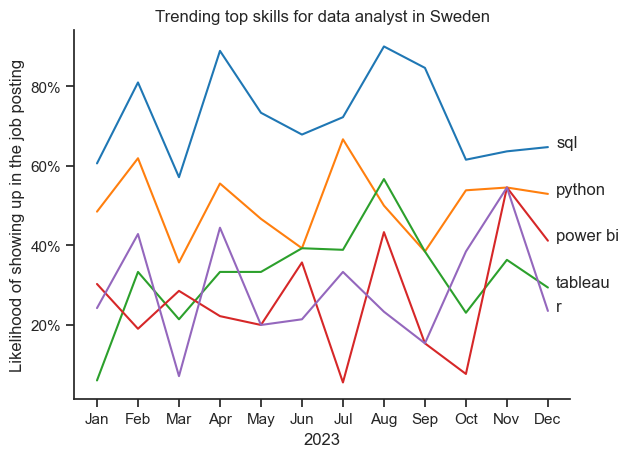

In [23]:
df_plot = df_SE_percent.iloc[:, :5]

sns.lineplot(df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending top skills for data analyst in Sweden')
plt.ylabel('Likelihood of showing up in the job posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])